In [1]:
import numpy as np
from scipy.special import gammaln,gammainc
from matplotlib import pyplot as plt
from numba import njit
from numba import vectorize, float64

np.random.seed(42)

In [2]:
@njit
def set_seed():
    np.random.seed(42)
set_seed()

In [3]:
@vectorize([float64(float64)])
def exp_sample(rate):
        return -np.log(np.random.rand()) / rate


@njit
def compile_run_poisson(beta,gamma=1,T=100):
    #print('fraction of time in active state',lact/(lina+lact))

    t = 0.
    R = np.random.poisson(beta)
    S = np.array((1,-1))
    #rates = lambda r: np.array((beta,r))

    ts = []
    rs = []

    while True:
        rates =  np.array((beta,R))

        #dt_prop = np.random.exponential(1/rates,size=1)
        dt_prop = exp_sample(rates)
        dt = np.min(dt_prop)
        reac = S[np.argmin(dt_prop)]

        if t+dt>T:
            rs.append(R)
            ts.append(T)
            return ts,rs

        t = t+dt
        rs.append(R)
        ts.append(t)

        R = R+reac
        rs.append(R)
        ts.append(t)


def forward_run_poisson(beta,gamma=1,T=100):
    t,s = compile_run_poisson(beta,gamma,T)
    return np.array(t),np.array(s)

@njit
def compile_run_cell_div(beta,divtime=1,T=100):
    #print('fraction of time in active state',lact/(lina+lact))

    t = 0
    tau = np.random.rand()
    t_in = tau

    R = np.random.poisson(beta*(1+tau))

    ts = []
    rs = []

    while True:
        #dt = np.random.exponential(1/beta)
        dt= exp_sample(beta)

        if t_in+dt>divtime:
            t = t + divtime
            t_in = 0

            rs.append(R)
            ts.append(t*1.0)
            
            R = np.random.binomial(R,.5)
            rs.append(R)
            ts.append(t*1.0)
            
            if t>=T+1:
                return [tsi-tau for tsi in ts],rs

        else:
            t_in = t_in + dt
            rs.append(R*1)
            ts.append(t+t_in)

            R = R+1
            rs.append(R*1)
            ts.append(t+t_in)  

compile_run_poisson(5,T=1)
compile_run_cell_div(5,T=1)

def forward_run_cell_div(beta,divtime=1,T=100):
    t,s = compile_run_cell_div(beta,divtime,T)
    t=np.array(t)
    return t[t<T],np.array(s)[t<T]




/tmp/ipykernel_173302/4208559208.py:66: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


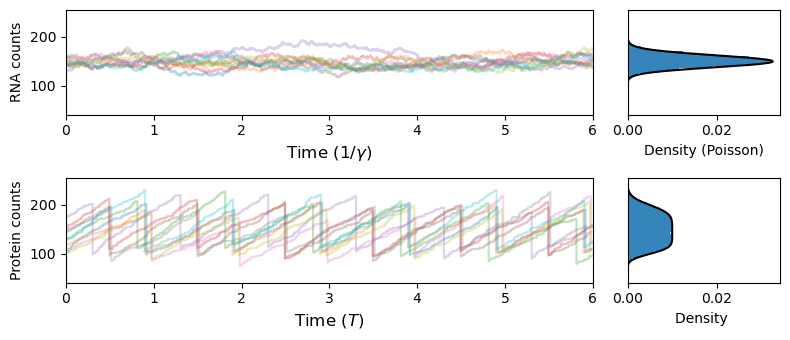

In [4]:
fig, ax  = plt.subplot_mosaic([['poi','poi','poi','poi_hist'],
                               ['div','div','div','div_hist']], layout='constrained',figsize=(8,3.5))

poisson_final = []
celldiv_final = []
beta = 150.
betap = beta/1.5


for i in range(100000):
    tp,rp = forward_run_poisson(beta,T=6)
    tcd,rcd = forward_run_cell_div(betap,T=6)
    if i<10:
        ax['poi'].plot(tp,rp,alpha=.3)
        ax['div'].plot(tcd,rcd,alpha=.3)
    poisson_final.append(rp[-1])
    celldiv_final.append(rcd[-1])

ax['poi'].set_xlabel(r'Time $(1/\gamma)$',fontsize=12)
ax['div'].set_xlabel(r'Time $(T)$',fontsize=12)

ax['poi'].set_xlim((0,6))
ax['div'].set_xlim((0,6))

ax['poi'].set_ylabel('RNA counts')
ax['div'].set_ylabel('Protein counts')

ax['poi_hist'].hist(poisson_final, bins=np.arange(50,250,5), orientation='horizontal', alpha=0.9, density=True)
ax['div_hist'].hist(celldiv_final, bins=np.arange(50,250,5), orientation='horizontal', alpha=0.9, density=True)

ax['poi_hist'].set_yticks([])
ax['div_hist'].set_yticks([])


# Get current y-axis limits
poi_ylim = ax['poi'].get_ylim()
poi_hist_ylim = ax['poi_hist'].get_ylim()
div_ylim = ax['div'].get_ylim()
div_hist_ylim = ax['div_hist'].get_ylim()

# Choose the broader range for each row
poi_min, poi_max = min(poi_ylim[0], poi_hist_ylim[0]), max(poi_ylim[1], poi_hist_ylim[1])
div_min, div_max = min(div_ylim[0], div_hist_ylim[0]), max(div_ylim[1], div_hist_ylim[1])

# Apply the wider y-limits
ax['poi'].set_ylim(poi_min, poi_max)
ax['poi_hist'].set_ylim(poi_min, poi_max)
ax['div'].set_ylim(div_min, div_max)
ax['div_hist'].set_ylim(div_min, div_max)


x = np.arange(poi_min,poi_max)
py = np.exp( x*np.log(beta)-beta-gammaln(1+x) )
ax['poi_hist'].plot(py,x,color='k')
ax['poi_hist'].set_xlabel('Density (Poisson)')


x = np.arange(div_min,div_max)

py = (1/betap)*(gammainc(x+1,2*betap)-gammainc(x+1,betap))
ax['div_hist'].plot(py,x,color='k')
ax['div_hist'].set_xlabel('Density ')
ax['div_hist'].set_xlim(ax['poi_hist'].get_xlim())


fig.tight_layout()
fig.savefig('f2.png',dpi=600)
